## Algorithm Of Colorimetry

## Import Libraries

In [1]:
import colour
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## Separación de Muestras

In [18]:

#Carga de los datos
input_filename = ('samples/test-colores-14-03-26/test-colores-14-03-26.csv')
data = pd.read_csv(input_filename, low_memory=False)

#Extraer las longitudes de onda 'Wavelength (nm)'
wavelengths = data.iloc[1:, 0]

#Extraer las reflectancias de cada muestra 'Reflectances (%R)' - a partir de la columna 5 (índice 4)
reflectances = data.iloc[1:, 1::2]

#Unir todo en un nuevo DataFrame
master_data = pd.concat([wavelengths, reflectances], axis=1)
num_samples = master_data.shape[1] - 1

#Asignamos los nombres al DataFrame
new_columns = ['Wavelength (nm)'] + [f'Reflectance POS {i} (%R)' for i in range(num_samples)]
master_data.columns = new_columns

#Todo lo que sea texto (el reporte del final) se convertirá en NaN (Not a Number) y se elimina
master_data['Wavelength (nm)'] = pd.to_numeric(master_data['Wavelength (nm)'], errors='coerce')
master_data = master_data.dropna(subset=['Wavelength (nm)'])

#Guardar datos procesados
# Crear carpeta si no existe
os.makedirs("data-processed", exist_ok=True)
base_name = os.path.splitext(os.path.basename(input_filename))[0]
output_filename = f"data-processed/{base_name}_processed.csv"
master_data.to_csv(output_filename, index=False)
print(f'Archivo procesado guardado con nombre {output_filename}')


Archivo procesado guardado con nombre data-processed/test-colores-14-03-26_processed.csv


## View Data

## Raw Data

In [19]:
data.head()

,POS0,Unnamed: 1,POS1,Unnamed: 3,POS2,Unnamed: 5,POS3,Unnamed: 7,POS4,Unnamed: 9,...,Unnamed: 63,POS32,Unnamed: 65,POS33,Unnamed: 67,POS34,Unnamed: 69,POS35,Unnamed: 71,Unnamed: 72
0,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,...,%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,NaN
1,1000.01416,14.88808823,1000.01416,15.1480999,1000.01416,15.76548386,1000.01416,15.81099033,1000.01416,15.78507233,...,15.81517601,1000.01416,16.16860008,1000.01416,16.07276154,1000.01416,16.15141106,1000.01416,15.98187256,NaN
2,999.0076904,15.06511974,999.0076904,15.08710861,999.0076904,15.79427528,999.0076904,16.02326393,999.0076904,15.70754051,...,15.87104988,999.0076904,16.09524727,999.0076904,15.84238434,999.0076904,15.89756489,999.0076904,16.14155769,NaN
3,998.0006714,14.96455479,998.0006714,15.11015034,998.0006714,15.55130291,998.0006714,15.80410004,998.0006714,15.55187416,...,15.89643192,998.0006714,16.19909286,998.0006714,16.11365318,998.0006714,16.01399612,998.0006714,16.029953,NaN
4,996.993042,14.73498631,996.993042,14.80087662,996.993042,15.65877628,996.993042,15.57874107,996.993042,15.54496002,...,15.75456429,996.993042,15.70850468,996.993042,16.00553131,996.993042,15.86763287,996.993042,15.87128067,NaN


## Processing Data

In [20]:
master_data.head()

,Wavelength (nm),Reflectance POS 0 (%R),Reflectance POS 1 (%R),Reflectance POS 2 (%R),Reflectance POS 3 (%R),Reflectance POS 4 (%R),Reflectance POS 5 (%R),Reflectance POS 6 (%R),Reflectance POS 7 (%R),Reflectance POS 8 (%R),...,Reflectance POS 26 (%R),Reflectance POS 27 (%R),Reflectance POS 28 (%R),Reflectance POS 29 (%R),Reflectance POS 30 (%R),Reflectance POS 31 (%R),Reflectance POS 32 (%R),Reflectance POS 33 (%R),Reflectance POS 34 (%R),Reflectance POS 35 (%R)
1,1000.014160,14.88808823,15.1480999,15.76548386,15.81099033,15.78507233,16.09719658,15.12008476,15.14489079,15.76624203,...,15.67419052,15.90722942,15.95839882,15.85105515,16.00347328,15.81517601,16.16860008,16.07276154,16.15141106,15.98187256
2,999.007690,15.06511974,15.08710861,15.79427528,16.02326393,15.70754051,16.22003555,15.07139397,14.88849354,15.71382427,...,15.77802467,15.84918213,16.09037399,15.94570923,16.02931023,15.87104988,16.09524727,15.84238434,15.89756489,16.14155769
3,998.000671,14.96455479,15.11015034,15.55130291,15.80410004,15.55187416,16.37279129,15.14738083,15.07589245,15.8131752,...,15.94757462,15.74559784,16.265728,15.85299969,15.77164078,15.89643192,16.19909286,16.11365318,16.01399612,16.029953
4,996.993042,14.73498631,14.80087662,15.65877628,15.57874107,15.54496002,16.19000816,15.15033436,14.95737457,15.63594341,...,15.89045334,15.94481754,16.10968018,15.71434116,15.91796398,15.75456429,15.70850468,16.00553131,15.86763287,15.87128067
5,995.984802,14.88867092,14.76780319,15.54154301,15.77867699,15.47938538,16.1899662,15.08384514,14.88455963,15.68521309,...,15.79159069,15.81272221,15.86397171,15.7818203,15.76531696,15.65077782,15.7442255,15.6688261,16.03845596,15.79868221


### Visualization of Spectrum

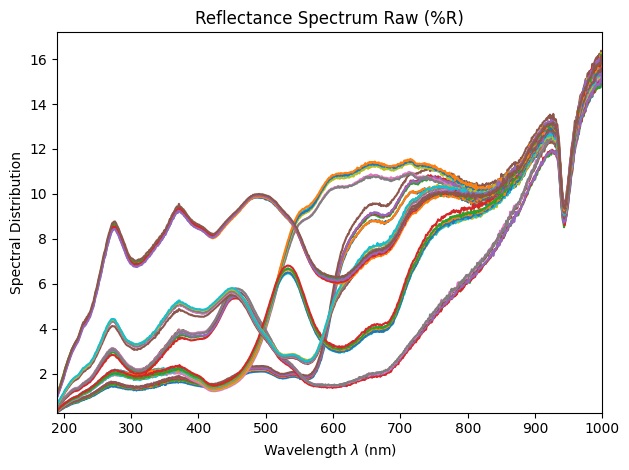

In [21]:
#Cargar datos
data_view = pd.read_csv('data-processed/test-colores-14-03-26_processed.csv')

#Organizar los datos de forma ascendente
data_view = data_view.set_index('Wavelength (nm)')
data_view = data_view.sort_index()

#Crear el objeto con datos crudos (0-100)
msds_raw = colour.MultiSpectralDistributions(data_view)

#Graficar los espectros crudos
fig, ax = colour.plotting.plot_multi_sds(
    msds_raw,
    title='Reflectance Spectrum Raw (%R)',
    legend=False
)
plt.show()

## Preprocessing Data to Color Parameters

### Negative Reflectance

In [ ]:
# Detectar negativos directamente en formato largo
data_processed = pd.read_csv(
    'data-processed/test-colores-14-03-26_processed.csv',
    low_memory=False
)

data_long = (
    data_processed
    .where(data_processed < 0)
    .stack()
    .reset_index()
)

data_long.columns = ['Row', 'Sample', 'Reflectance (%R)']

# Agregar longitud de onda
data_long['Wavelength (nm)'] = data_long['Row'].map(
    data_processed[wavelength_col]
)

print(data_long)

NameError: name 'wavelength_col' is not defined

In [22]:
data_processed = pd.read_csv('data-processed/test-colores-14-03-26_processed.csv')

### Set negative reflectance values to zero and normalize

In [23]:
#Crear una copia de los datos procesados
data_normalized = data_processed.copy(deep=True)
data_normalized = data_normalized.set_index('Wavelength (nm)')
data_normalized = data_normalized.sort_index(ascending=True)

#Cambiar los valores negativos a 0
data_normalized[data_normalized < 0] = 0

#Normalizar los % de reflectancia entre 100 (Factor de 0 a 1)
data_normalized = data_normalized / 100.0

In [24]:
data_normalized

,Reflectance POS 0 (%R),Reflectance POS 1 (%R),Reflectance POS 2 (%R),Reflectance POS 3 (%R),Reflectance POS 4 (%R),Reflectance POS 5 (%R),Reflectance POS 6 (%R),Reflectance POS 7 (%R),Reflectance POS 8 (%R),Reflectance POS 9 (%R),...,Reflectance POS 26 (%R),Reflectance POS 27 (%R),Reflectance POS 28 (%R),Reflectance POS 29 (%R),Reflectance POS 30 (%R),Reflectance POS 31 (%R),Reflectance POS 32 (%R),Reflectance POS 33 (%R),Reflectance POS 34 (%R),Reflectance POS 35 (%R)
Wavelength (nm),,,,,,,,,,,,,,,,,,,,,
190.015442,0.002565,0.002830,0.002917,0.002839,0.003030,0.002991,0.003278,0.003681,0.003357,0.003757,...,0.005989,0.006207,0.006045,0.006378,0.009822,0.010718,0.010809,0.009785,0.009441,0.010444
191.005661,0.002934,0.003103,0.002962,0.002998,0.003134,0.003069,0.003529,0.003899,0.003909,0.004044,...,0.006323,0.006632,0.006580,0.006793,0.010344,0.011303,0.011695,0.010684,0.009884,0.011224
191.995804,0.003024,0.003391,0.003383,0.003472,0.003156,0.003385,0.003697,0.004231,0.004090,0.004319,...,0.007143,0.007287,0.007062,0.007476,0.011470,0.012546,0.012497,0.011669,0.011110,0.012369
192.985886,0.003187,0.003522,0.003415,0.003469,0.003522,0.003537,0.004096,0.004314,0.004190,0.004538,...,0.007427,0.007614,0.007538,0.007849,0.012178,0.013149,0.013301,0.012352,0.011708,0.013082
194.015488,0.003429,0.003704,0.003776,0.003750,0.003733,0.003738,0.004163,0.004628,0.004555,0.004800,...,0.008002,0.008224,0.008011,0.008450,0.013016,0.014100,0.014261,0.013164,0.012606,0.013857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995.984802,0.148887,0.147678,0.155415,0.157787,0.154794,0.161900,0.150838,0.148846,0.156852,0.157921,...,0.157916,0.158127,0.158640,0.157818,0.157653,0.156508,0.157442,0.156688,0.160385,0.157987
996.993042,0.147350,0.148009,0.156588,0.155787,0.155450,0.161900,0.151503,0.149574,0.156359,0.157563,...,0.158905,0.159448,0.161097,0.157143,0.159180,0.157546,0.157085,0.160055,0.158676,0.158713
998.000671,0.149646,0.151102,0.155513,0.158041,0.155519,0.163728,0.151474,0.150759,0.158132,0.157920,...,0.159476,0.157456,0.162657,0.158530,0.157716,0.158964,0.161991,0.161137,0.160140,0.160300


### Create MultiSpectralDistribution and XYZ Values

In [25]:
#Crear objeto
msds = colour.MultiSpectralDistributions(data_normalized)

#Verificamos la dimension y la forma de los espectros (Valor Max, Valor Min, Saltos)
print(msds.shape)
print(msds.domain[:5])

#Definimos nueva forma de nuestro espectro en el rango visible
shape = colour.SpectralShape(360, 750, 1)

#Interpolacion de los espectros para que los saltos sean de 1nm
msds = msds.align(shape)

#Cargar estandares de la CIE
cmfs = colour.MSDS_CMFS['CIE 1931 2 Degree Standard Observer']
illuminant = colour.SDS_ILLUMINANTS['D65']

#Calculo XYZ
XYZ = colour.msds_to_XYZ(msds, cmfs, illuminant)

#Visualizar valores XYZ calculados
print("Dimensión de XYZ:", XYZ.shape)
print("Valores XYZ:\n", XYZ)

(190.0154419, 1000.01416, 0.9638060999999993)
[ 190.0154419  191.005661   191.9958038  192.9858856  194.0154877]
Dimensión de XYZ: (36, 3)
Valores XYZ:
 [[ 3.87208672  2.89607522  1.88143475]
 [ 3.95666352  2.98184933  1.96296446]
 [ 4.06908588  3.07115661  2.01597797]
 [ 4.07000935  3.04951399  2.02567947]
 [ 4.0648074   3.0606649   2.03680733]
 [ 4.2625541   3.20329017  2.1124837 ]
 [ 7.80012097  8.10448858  2.03235113]
 [ 7.79616066  8.10413596  2.13582372]
 [ 8.07096441  8.3681133   2.11160458]
 [ 8.18606134  8.4947141   2.22562741]
 [ 8.16241559  8.47091246  2.19471833]
 [ 8.24008353  8.57300112  2.17658254]
 [ 2.14513977  2.15976066  5.32677104]
 [ 2.09152543  2.10651582  5.21584898]
 [ 2.16127831  2.18228422  5.29576309]
 [ 2.20986073  2.23195057  5.50736608]
 [ 2.23489637  2.25598263  5.61722074]
 [ 2.24405224  2.25790138  5.63865685]
 [ 3.28279847  4.63486749  2.33919505]
 [ 3.23210293  4.59033197  2.25530914]
 [ 3.254906    4.61675994  2.3056281 ]
 [ 3.33112627  4.71720856  2

## Calculate CIELab (L* a* b*)

In [26]:
#Definir punto blanco para el iluminante D65
illuminant_xy = colour.CCS_ILLUMINANTS['CIE 1931 2 Degree Standard Observer']['D65']

#Usamos los valores XYZ para calcular CIELab
Lab = colour.XYZ_to_Lab(XYZ, illuminant=illuminant_xy)

#Visualizar valores Lab calculados
print('Valores CIELab calculados.')
print("Valores (L, a, b):\n", Lab)

Valores CIELab calculados.
Valores (L, a, b):
 [[ 149.34634588   85.86050751   45.09933741]
 [ 150.96286478   84.66516262   44.46891543]
 [ 152.61335785   85.09788406   45.14288819]
 [ 152.21634761   86.87054837   44.06509881]
 [ 152.42113264   85.64178851   43.96860782]
 [ 154.99762679   87.48933077   45.39610112]
 [ 217.00569046    4.20511579  155.50112836]
 [ 217.00231108    4.04896631  151.38548286]
 [ 219.505203      4.97196437  156.65066532]
 [ 220.68691264    4.70451204  154.27763371]
 [ 220.46564538    4.6704711   155.07654302]
 [ 221.41179013    3.8296511   157.40559202]
 [ 133.94311591    9.55356185  -80.97315756]
 [ 132.70066046    9.39875058  -80.74227561]
 [ 134.46255304    8.95524576  -79.41754156]
 [ 135.59545477    8.96214554  -81.91841145]
 [ 136.1376042     9.11732805  -83.25117917]
 [ 136.18072391    9.83818883  -83.61584206]
 [ 177.4062169   -77.84656437   75.41019822]
 [ 176.78475483  -79.0786059    77.46096786]
 [ 177.15402107  -78.90617224   76.21564453]
 [ 178.5

## Visualization of XYZ in sRGB

Muestras fuera de gamut sRGB: 36 de 36


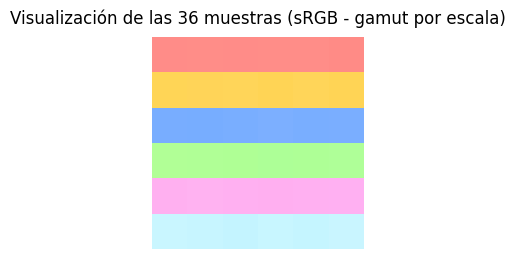

In [28]:

# Convertimos los tristimulos XYZ a sRGB
RGB = colour.XYZ_to_sRGB(XYZ, illuminant=illuminant_xy)

# ── Gamut mapping por escala (preserva tono, reduce saturación) ──────────────
RGB_mapped = np.clip(RGB, 0, None)
max_per_sample = RGB_mapped.max(axis=1, keepdims=True)
scale = np.where(max_per_sample > 1, max_per_sample, 1.0)
RGB_mapped = RGB_mapped / scale

n = RGB_mapped.shape[0]
cols = 6
rows = int(np.ceil(n / cols))

# Rellenar hasta completar la rejilla (fila por fila)
pad = rows * cols - n
if pad > 0:
    RGB_mapped = np.vstack([RGB_mapped, np.ones((pad, 3))])  # relleno blanco

# Reshape a imagen (rows, cols, 3) — fila por fila, sin rotación
img = RGB_mapped.reshape(rows, cols, 3)
img = np.fliplr(img)  # espejo horizontal

print(f"Muestras fuera de gamut sRGB: {(RGB.max(axis=1) > 1).sum()} de {n}")

fig, ax = plt.subplots(figsize=(cols * 0.45, rows * 0.45))
ax.imshow(img, aspect='equal', interpolation='nearest')
ax.set_title(f'Visualización de las {n} muestras (sRGB - gamut por escala)', pad=10)
ax.axis('off')
plt.tight_layout()
plt.show()


## Visualization of Lab in sRGB

Muestras fuera de gamut sRGB (desde Lab): 36 de 36


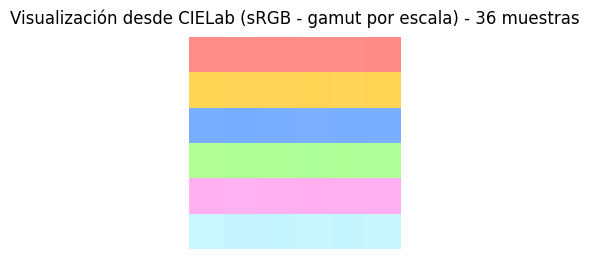

In [29]:

# Lab -> XYZ -> sRGB con gamut mapping por escala
XYZ_from_Lab = colour.Lab_to_XYZ(Lab, illuminant=illuminant_xy)
RGB_from_Lab = colour.XYZ_to_sRGB(XYZ_from_Lab, illuminant=illuminant_xy)

RGB_from_Lab = np.clip(RGB_from_Lab, 0, None)
max_per_sample = RGB_from_Lab.max(axis=1, keepdims=True)
scale = np.where(max_per_sample > 1, max_per_sample, 1.0)
RGB_from_Lab_mapped = RGB_from_Lab / scale

n = RGB_from_Lab_mapped.shape[0]
cols = 6
rows = int(np.ceil(n / cols))

# Rellenar hasta completar la rejilla (fila por fila)
pad = rows * cols - n
if pad > 0:
    RGB_from_Lab_mapped = np.vstack([RGB_from_Lab_mapped, np.ones((pad, 3))])

# Reshape a imagen (rows, cols, 3) — fila por fila, sin rotación
img_lab = RGB_from_Lab_mapped.reshape(rows, cols, 3)
img_lab = np.fliplr(img_lab)  # espejo horizontal

print(f"Muestras fuera de gamut sRGB (desde Lab): {(RGB_from_Lab.max(axis=1) > 1).sum()} de {n}")

fig, ax = plt.subplots(figsize=(cols * 0.45, rows * 0.45))
ax.imshow(img_lab, aspect='equal', interpolation='nearest')
ax.set_title(f'Visualización desde CIELab (sRGB - gamut por escala) - {n} muestras', pad=10)
ax.axis('off')
plt.tight_layout()
plt.show()
